# IaCGen Baseline Audit — DeepSeek V4 Flash

Evaluates a single-agent IaCGen baseline run (`../IaCGen/`, no security scanning, no
multi-agent remediation — just iterative generate → validate → deploy feedback) against
this project's own real-AWS L3–L5 CloudFormation benchmark (`cfn_eval_benchmark_real_aws_diff345.csv`),
as a point of comparison for IaCGOD's own multi-agent results elsewhere in this repo.

Mirrors the visualization style of `IaCGOD_Coverage_Audit_Result.ipynb` / `IaCGOD_TF_Coverage_Audit_Result.ipynb`
(ggplot + muted palette, count-annotated pass-rate bars, message-labeled error-code plots) so the three
notebooks read as one consistent system, not three different styles.

In [1]:
import os
import re
import json
import glob
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------------------------
# Paths -- this notebook lives in data_analysis/, and evaluates a single
# baseline run of IaCGen (../IaCGen/) against our own real-AWS L3/4/5
# CloudFormation benchmark. Structured as `input_pairs` (one entry today) so
# another baseline/model run can be added later the same way the other
# *_Audit_Result.ipynb notebooks do.
# ---------------------------------------------------------------------------
input_pairs = [
    {
        "model_name": "IaCGen_DeepseekV4Flash",
        "results_csv": "result/iacgod/baseline-iacgen/deepseek-v4-flash_results.csv",
        "error_history_csv": "result/iacgod/baseline-iacgen/deepseek-v4-flash_error_history.csv",
        "templates_dir": "result/iacgod/baseline-iacgen/deepseek-v4-flash",
    },
]

BENCHMARK_CSV = "cfn_benchmark/dataset/cfn_eval_benchmark_real_aws_diff345.csv"
CFN_BENCHMARK_BASE = "cfn_benchmark"


## 1. Normalize Results Against the Benchmark

Aligns IaCGen's own results CSV (blank `ground_truth_path`, stale `final_template_path`) to the real benchmark and to the actual on-disk generated templates, and removes any row_number that was run twice.

In [2]:
# ── 1. Normalize each baseline's results against the benchmark ────────────
# The raw `*_results.csv` IaCGen writes never fills in `ground_truth_path`
# (that column is left blank at write time). Its own `row_number` is only a
# label IaCGen assigned that run -- NOT a stable identifier, and not
# trustworthy as a positional index into the benchmark either, since a
# rerun-and-resave of the harness could reorder or reassign it. So ground
# truth is recovered by CONTENT, not position: each row's own `prompt` text
# (which IS populated) is matched against the benchmark's own `prompt`
# column to find its `ground_truth_path` -- position/row_number is never
# used for the join. This also makes it possible to directly detect the
# thing this method exists to catch: the same ground-truth scenario showing
# up under two different row_numbers (not just literal row_number repeats).
#
# One text wrinkle handled before matching: IaCGen's own CSV writer round-
# tripped some prompts through a UTF-8-bytes-read-as-Latin-1 decode
# (corrupting em-dashes/apostrophes into "â\x80\x94" / "â\x80\x99"); undone
# here so those rows still match their benchmark prompt exactly rather than
# being reported as unmatched.

def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return s

bench = pd.read_csv(BENCHMARK_CSV).reset_index(drop=True)
print(f"📐 Benchmark: {BENCHMARK_CSV} ({len(bench)} rows, difficulty {sorted(bench['difficulty'].unique())})")

dup_bench_prompts = bench["prompt"][bench["prompt"].duplicated(keep=False)]
if len(dup_bench_prompts):
    print(f"⚠️  Benchmark itself has {dup_bench_prompts.duplicated().sum()} duplicate prompt(s) "
          f"-- ground-truth matching will be ambiguous for those rows.")
bench_prompt_to_idx = {}
for i, p in enumerate(bench["prompt"]):
    bench_prompt_to_idx.setdefault(p, []).append(i)

normalized_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    raw = pd.read_csv(pair["results_csv"])
    n_raw = len(raw)
    raw["prompt_fixed"] = raw["prompt"].apply(fix_mojibake)

    matches = raw["prompt_fixed"].map(lambda p: bench_prompt_to_idx.get(p, []))
    n_zero, n_multi = (matches.apply(len) == 0).sum(), (matches.apply(len) > 1).sum()
    if n_zero or n_multi:
        print(f"\n⚠️  {model}: {n_zero} row(s) matched NO benchmark prompt, "
              f"{n_multi} row(s) matched MORE THAN ONE (ambiguous) -- excluded from analysis below.")
        bad_cols = [c for c in ["row_number", "prompt"] if c in raw.columns]
        with pd.option_context("display.max_colwidth", 60):
            print(raw.loc[matches.apply(len) != 1, bad_cols].to_string(index=False))

    raw["bench_idx"] = matches.apply(lambda l: l[0] if len(l) == 1 else None)
    raw = raw[raw["bench_idx"].notna()].copy()
    raw["bench_idx"] = raw["bench_idx"].astype(int)
    raw["ground_truth_path"] = bench.loc[raw["bench_idx"], "ground_truth_path"].values
    raw["difficulty"] = bench.loc[raw["bench_idx"], "difficulty"].values
    raw["benchmark_prompt"] = bench.loc[raw["bench_idx"], "prompt"].values

    # The actual duplicate check: the SAME ground_truth_path claimed by more than
    # one row (whether under the same row_number or, critically, two different
    # ones) means that scenario was run more than once end-to-end.
    dup_gt = raw["ground_truth_path"].value_counts()
    dup_gt = dup_gt[dup_gt > 1]
    if len(dup_gt):
        print(f"\n⚠️  {model}: {len(dup_gt)} ground_truth_path(s) claimed by more than one row "
              f"-- keeping the most recent rerun for each, dropping the earlier attempt(s):")
        cols = [c for c in ["row_number", "ground_truth_path", "success", "total_iterations", "final_template_path"] if c in raw.columns]
        with pd.option_context("display.max_colwidth", 55):
            print(raw[raw["ground_truth_path"].isin(dup_gt.index)][cols].to_string(index=False))

    df = (raw.sort_values("row_number", kind="stable")
             .drop_duplicates(subset="ground_truth_path", keep="last")
             .reset_index(drop=True))

    df["resolved_ground_truth_path"] = df["ground_truth_path"].apply(
        lambda p: os.path.join(CFN_BENCHMARK_BASE, p) if isinstance(p, str) else None)
    df["resolved_generated_path"] = df["final_template_path"].apply(
        lambda p: os.path.join(pair["templates_dir"], os.path.basename(p)) if isinstance(p, str) else None)

    gt_missing = ~df["resolved_ground_truth_path"].apply(lambda p: os.path.isfile(p) if p else False)
    gen_missing = ~df["resolved_generated_path"].apply(lambda p: os.path.isfile(p) if p else False)

    normalized_dataframes[model] = df

    print(f"\n✅ {model}: {n_raw} raw rows -> {len(df)} normalized rows "
          f"(dropped {n_raw - len(df)} row(s): {n_zero + n_multi} unmatched/ambiguous, "
          f"{n_raw - n_zero - n_multi - len(df)} duplicate-scenario rerun(s)).")
    print(f"   Ground-truth files resolved: {(~gt_missing).sum()}/{len(df)}; "
          f"generated-template files resolved: {(~gen_missing).sum()}/{len(df)}.")
    if gt_missing.any() or gen_missing.any():
        print(f"   ⚠️ Missing files -- these rows will be excluded from coverage/error analysis below:")
        display(df.loc[gt_missing | gen_missing, ["row_number", "ground_truth_path", "final_template_path"]])

    unclaimed_bench = len(bench) - df["ground_truth_path"].nunique()
    if unclaimed_bench:
        print(f"   ℹ️ {unclaimed_bench} benchmark scenario(s) in this difficulty range were never run by this baseline.")

    out_path = pair["results_csv"].replace(".csv", "_normalized.csv")
    df.drop(columns=["benchmark_prompt", "prompt_fixed", "bench_idx"]).to_csv(out_path, index=False)
    print(f"   Saved normalized CSV -> {out_path}")


📐 Benchmark: cfn_benchmark/dataset/cfn_eval_benchmark_real_aws_diff345.csv (150 rows, difficulty [np.int64(3), np.int64(4), np.int64(5)])

⚠️  IaCGen_DeepseekV4Flash: 1 ground_truth_path(s) claimed by more than one row -- keeping the most recent rerun for each, dropping the earlier attempt(s):
 row_number                                                                                                    ground_truth_path  success  total_iterations                                                                                                                 final_template_path
         20 cfn_templates_greenfield/chrictoria2025__AI/02-use-cases/AWS-operations-agent/mcp-tool-lambda/mcp-tool-template.yaml     True                 5  llm_generated_data/template/iterative/deepseek/openrouter/deepseek/deepseek-v4-flash/row_20_update_5_template_20260904_062514.yaml
         20 cfn_templates_greenfield/chrictoria2025__AI/02-use-cases/AWS-operations-agent/mcp-tool-lambda/mcp-tool-template.yaml 

## 2. Pass Rate Analytics

📊 Overall Pass Rates:
  -> IaCGen_DeepseekV4Flash: 126/150 (84.0%)


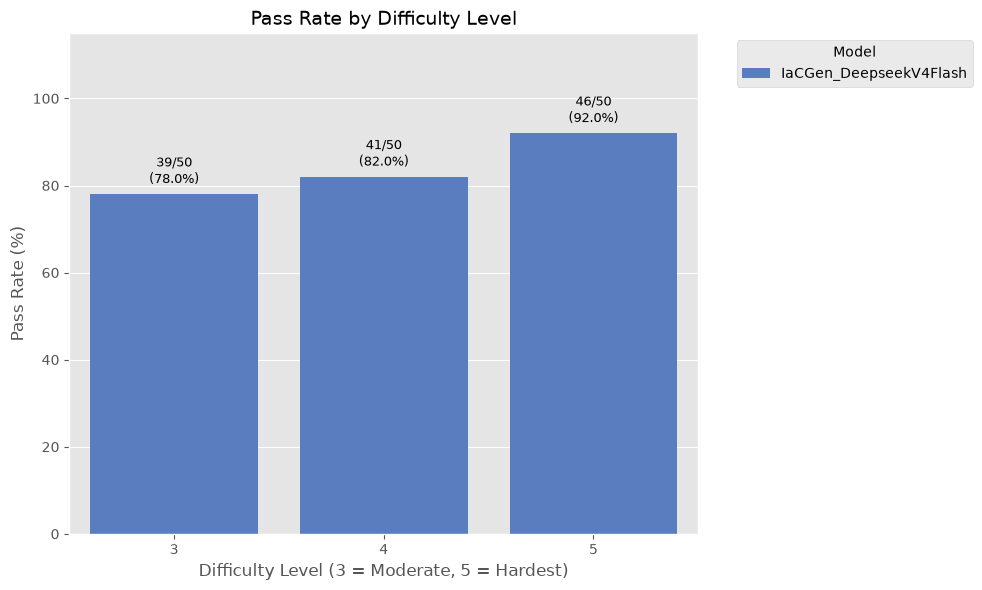

In [3]:
# ── 2. Pass Rate by Difficulty ──────────────────────────────────────────────
difficulty_stats = []

print("📊 Overall Pass Rates:")
for model_name, df in normalized_dataframes.items():
    total_passed = int(df["success"].sum())
    total_scenarios = len(df)
    overall_rate = (total_passed / total_scenarios * 100) if total_scenarios else 0
    print(f"  -> {model_name}: {total_passed}/{total_scenarios} ({overall_rate:.1f}%)")

    grouped = df.groupby("difficulty")["success"].agg(["sum", "count", "mean"])
    for diff, row in grouped.iterrows():
        difficulty_stats.append({
            "Model": model_name, "Difficulty Level": diff,
            "Passed": int(row["sum"]), "Total": int(row["count"]), "Pass Rate (%)": row["mean"] * 100,
        })

if difficulty_stats:
    diff_df = pd.DataFrame(difficulty_stats)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=diff_df, x="Difficulty Level", y="Pass Rate (%)", hue="Model")
    plt.title("Pass Rate by Difficulty Level", fontsize=14)
    plt.ylim(0, 115)
    plt.xlabel("Difficulty Level (3 = Moderate, 5 = Hardest)")
    plt.ylabel("Pass Rate (%)")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    for i, container in enumerate(ax.containers):
        model_name = ax.get_legend().get_texts()[i].get_text()
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue
            diff_level = ax.get_xticklabels()[j].get_text()
            row = diff_df[(diff_df["Model"] == model_name) & (diff_df["Difficulty Level"].astype(str) == diff_level)]
            if not row.empty:
                passed, total, rate = row["Passed"].values[0], row["Total"].values[0], row["Pass Rate (%)"].values[0]
                ax.annotate(f"{passed}/{total}\n({rate:.1f}%)", (p.get_x() + p.get_width() / 2., height),
                            ha="center", va="bottom", xytext=(0, 5), textcoords="offset points", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find difficulty or validation columns to plot Pass Rate.")


📊 Calculating Cumulative Pass Rates by Iteration Milestones...


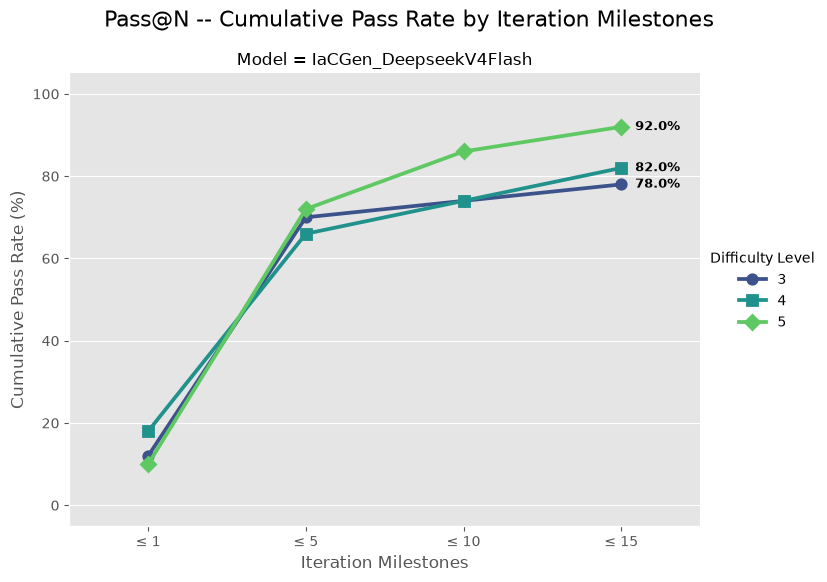


📊 Overall Pass@N (all difficulties combined):


Model,IaCGen_DeepseekV4Flash
N,
1,13.3
5,69.3
10,78.0
15,84.0


In [4]:
# ── 3. Pass@N (cumulative pass rate by iteration budget) ──────────────────
# pass@N here means: of all scenarios, what fraction ultimately succeeded AND
# did so within N iterations of IaCGen's own generate/validate/feedback loop
# -- i.e. "if the iteration budget had been capped at N, what pass rate would
# we still see." IaCGen's own max budget for this run is 15 iterations.
target_iterations = [1, 5, 10, 15]
iteration_stats = []

print("📊 Calculating Cumulative Pass Rates by Iteration Milestones...")
for model_name, df in normalized_dataframes.items():
    for diff in sorted(df["difficulty"].dropna().unique()):
        subset = df[df["difficulty"] == diff]
        total_in_diff = len(subset)
        if total_in_diff == 0:
            continue
        for t_iter in target_iterations:
            passed_subset = subset[(subset["success"] == True) & (subset["total_iterations"] <= t_iter)]
            iteration_stats.append({
                "Model": model_name, "Difficulty Level": str(diff),
                "Iteration Limit": f"≤ {t_iter}", "Iteration_Num": t_iter,
                "Pass Rate (%)": len(passed_subset) / total_in_diff * 100,
            })

if iteration_stats:
    iter_df = pd.DataFrame(iteration_stats).sort_values(by=["Model", "Difficulty Level", "Iteration_Num"])

    g = sns.catplot(
        data=iter_df, kind="point",
        x="Iteration Limit", y="Pass Rate (%)", hue="Difficulty Level", col="Model",
        palette="viridis", height=5.5, aspect=1.3,
        markers=["o", "s", "D", "^", "v"][:len(iter_df["Difficulty Level"].unique())],
        linestyles="-",
    )
    g.set_axis_labels("Iteration Milestones", "Cumulative Pass Rate (%)")
    g.set(ylim=(-5, 105))
    g.fig.suptitle("Pass@N -- Cumulative Pass Rate by Iteration Milestones", fontsize=16, y=1.05)

    for ax in g.axes.flat:
        for line in ax.lines:
            if len(line.get_xdata()) > 0:
                x_last, y_last = line.get_xdata()[-1], line.get_ydata()[-1]
                if pd.notna(y_last):
                    ax.annotate(f"{y_last:.1f}%", xy=(x_last, y_last), xytext=(10, 0),
                                textcoords="offset points", ha="left", va="center", fontsize=9, fontweight="bold")
    plt.show()

    print("\n📊 Overall Pass@N (all difficulties combined):")
    overall_rows = []
    for model_name, df in normalized_dataframes.items():
        for t_iter in target_iterations:
            passed = ((df["success"] == True) & (df["total_iterations"] <= t_iter)).sum()
            overall_rows.append({"Model": model_name, "N": t_iter, "Passed": int(passed), "Total": len(df),
                                  "Pass@N (%)": passed / len(df) * 100})
    display(pd.DataFrame(overall_rows).pivot(index="N", columns="Model", values="Pass@N (%)").round(1))
else:
    print("⚠️ No valid data processed for iteration milestones.")


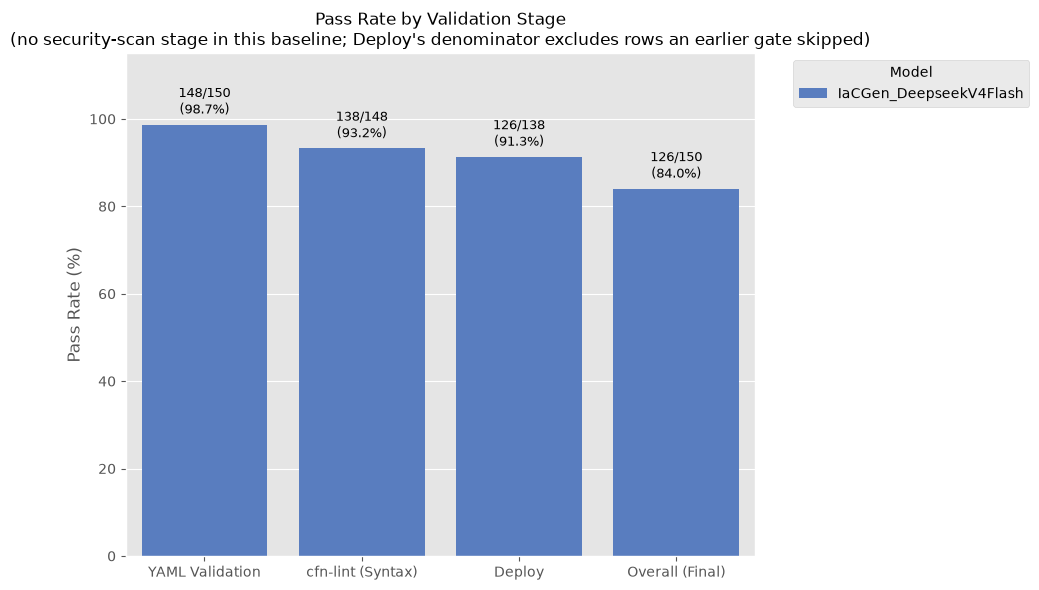

📊 Stage pass rates -- 'Total' is scenarios that actually reached that stage:


,Model,Stage,Passed,Total,Pass Rate (%)
0,IaCGen_DeepseekV4Flash,YAML Validation,148,150,98.7
1,IaCGen_DeepseekV4Flash,cfn-lint (Syntax),138,148,93.2
2,IaCGen_DeepseekV4Flash,Deploy,126,138,91.3
3,IaCGen_DeepseekV4Flash,Overall (Final),126,150,84.0


In [5]:
# ── 4. Pass Rate by Validation Stage ───────────────────────────────────────
# IaCGen's own pipeline (Code/main.py, IterativeTemplateGenerator.evaluate_template)
# gates strictly sequentially per iteration and returns at the FIRST failing
# stage: YAML syntax -> CFN-lint/schema syntax -> Deploy. A later stage is
# never attempted once an earlier one fails that iteration -- there is no
# security-scan stage in this baseline at all (unlike IaCGOD's own pipeline).
# `failed_at_stage` in the results CSV already records exactly which stage
# stopped the FINAL iteration (None if it succeeded), so each stage's
# "reached" denominator is derived from that directly -- a stage after the
# recorded failure was never reached, and must not be counted as untested
# rather than skipped, or as a pass.
FAIL_STAGE_ORDER = ["yaml_validation", "syntax_validation", "deployment"]
STAGE_LABELS = {"yaml_validation": "YAML Validation", "syntax_validation": "cfn-lint (Syntax)", "deployment": "Deploy"}

def stage_status(row) -> dict:
    """{stage: 'passed'|'failed'|'skipped'} for the 3 IaCGen pipeline stages,
    derived from success/failed_at_stage under the sequential-gating rule above."""
    if row["success"] is True:
        return {s: "passed" for s in FAIL_STAGE_ORDER}
    fail_stage = row["failed_at_stage"]
    status, reached_fail = {}, False
    for s in FAIL_STAGE_ORDER:
        if reached_fail:
            status[s] = "skipped"
        elif s == fail_stage:
            status[s] = "failed"
            reached_fail = True
        else:
            status[s] = "passed"
    return status

stage_pass_rows = []
for model_name, df in normalized_dataframes.items():
    statuses = df.apply(stage_status, axis=1)
    for stage in FAIL_STAGE_ORDER:
        vals = statuses.apply(lambda d: d[stage])
        reached = (vals != "skipped").sum()
        passed = (vals == "passed").sum()
        if reached:
            stage_pass_rows.append({"Model": model_name, "Stage": STAGE_LABELS[stage],
                                     "Passed": int(passed), "Total": int(reached),
                                     "Pass Rate (%)": passed / reached * 100})
    n = len(df)
    p = int((df["success"] == True).sum())
    stage_pass_rows.append({"Model": model_name, "Stage": "Overall (Final)", "Passed": p, "Total": n,
                             "Pass Rate (%)": p / n * 100 if n else 0})

stage_df = pd.DataFrame(stage_pass_rows)
stage_order = [STAGE_LABELS[s] for s in FAIL_STAGE_ORDER] + ["Overall (Final)"]
stage_df["Stage"] = pd.Categorical(stage_df["Stage"], categories=stage_order, ordered=True)
stage_df = stage_df.sort_values(["Stage", "Model"])

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=stage_df, x="Stage", y="Pass Rate (%)", hue="Model", order=stage_order)
plt.title("Pass Rate by Validation Stage\n(no security-scan stage in this baseline; Deploy's denominator excludes rows an earlier gate skipped)", fontsize=12)
plt.ylim(0, 115)
plt.xlabel("")
plt.ylabel("Pass Rate (%)")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

for i, container in enumerate(ax.containers):
    model_name = ax.get_legend().get_texts()[i].get_text()
    for j, p in enumerate(container):
        height = p.get_height()
        if pd.isna(height) or (height == 0 and p.get_y() == 0):
            continue
        stage_label = ax.get_xticklabels()[j].get_text()
        row = stage_df[(stage_df["Model"] == model_name) & (stage_df["Stage"].astype(str) == stage_label)]
        if not row.empty:
            passed, total, rate = row["Passed"].values[0], row["Total"].values[0], row["Pass Rate (%)"].values[0]
            ax.annotate(f"{passed}/{total}\n({rate:.1f}%)", (p.get_x() + p.get_width() / 2., height),
                        ha="center", va="bottom", xytext=(0, 5), textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.show()

print("📊 Stage pass rates -- 'Total' is scenarios that actually reached that stage:")
display(stage_df[["Model", "Stage", "Passed", "Total", "Pass Rate (%)"]].round(1).reset_index(drop=True))


## 3. Resource Coverage & Accuracy

Computed here (this run skipped IaCGen's own coverage step) using IaCGen's own `get_required_resource_types` / `analyze_resource_coverage` logic, ported verbatim from `Code/evaluation/cloud_evaluation.py`.

In [6]:
# ── 5. Resource Coverage & Accuracy ─────────────────────────────────────────
# This run skipped IaCGen's own coverage step when it was collected (its
# `coverage_percentage`/`accuracy_percentage` columns are empty), so it's
# computed here instead -- using IaCGen's own logic verbatim
# (Code/evaluation/cloud_evaluation.py: get_required_resource_types +
# analyze_resource_coverage), not this repo's own audit/coverage_audit.py.
# Both compute the same kind of multiset resource-type coverage, but the
# point here is fidelity to what IaCGen itself would have reported, so the
# JSON-by-extension detection, the exact CFN-intrinsic-tag list, and the
# min/missing/extra multiset arithmetic are all ported unchanged.
#
# IaCGen's own evaluate_template() only ever skips this step (coverage = 0%)
# for a template that never produced valid YAML in the first place; a
# template that failed cfn-lint or deploy still gets scored, since it's still
# parseable. That same rule is followed here.

class _CFNLoader(yaml.SafeLoader):
    pass

def _construct_cfn_tag(loader, node):
    if isinstance(node, yaml.ScalarNode):
        return node.value
    elif isinstance(node, yaml.SequenceNode):
        return loader.construct_sequence(node)
    elif isinstance(node, yaml.MappingNode):
        return loader.construct_mapping(node)

for _tag in ['!Ref', '!Sub', '!GetAtt', '!Join', '!Select', '!Split', '!Equals', '!If',
             '!FindInMap', '!GetAZs', '!Base64', '!Cidr', '!Transform', '!ImportValue',
             '!Not', '!And', '!Or', '!Condition', '!ForEach', '!ValueOf', '!Rain::Embed']:
    _CFNLoader.add_constructor(_tag, _construct_cfn_tag)

def get_required_resource_types(template_path: str) -> list:
    """Port of IaCGen's own get_required_resource_types."""
    is_json = template_path.lower().endswith('.json')
    with open(template_path, 'r') as f:
        template = json.load(f) if is_json else yaml.load(f, Loader=_CFNLoader)
    resources = (template or {}).get('Resources', {}) or {}
    return [r['Type'] for r in resources.values() if isinstance(r, dict) and 'Type' in r]

def analyze_resource_coverage(required_resources: list, generated_resources: list) -> dict:
    """Port of IaCGen's own analyze_resource_coverage (multiset comparison)."""
    required_counts, generated_counts = {}, {}
    for r in required_resources:
        required_counts[r] = required_counts.get(r, 0) + 1
    for r in generated_resources:
        generated_counts[r] = generated_counts.get(r, 0) + 1

    all_types = set(required_counts) | set(generated_counts)
    correct, missing, extra = [], [], []
    for t in all_types:
        req, gen = required_counts.get(t, 0), generated_counts.get(t, 0)
        correct.extend([t] * min(req, gen))
        if req > gen:
            missing.extend([t] * (req - gen))
        if gen > req:
            extra.extend([t] * (gen - req))

    return {
        "total_required_resources": len(required_resources), "total_generated_resources": len(generated_resources),
        "correct_resources": len(correct), "missing_resources": len(missing), "extra_resources": len(extra),
        "coverage_percentage": (len(correct) / len(required_resources) * 100) if required_resources else 0.0,
        "accuracy_percentage": (len(correct) / len(generated_resources) * 100) if generated_resources else 0.0,
        "missing_resource_types": missing, "extra_resource_types": extra,
    }

for model_name, df in normalized_dataframes.items():
    cov_rows = []
    n_errors = 0
    for _, row in df.iterrows():
        result = {
            "coverage_pct": None, "accuracy_pct": None,
            "total_required_resources": None, "total_generated_resources": None,
            "correct_resources": None, "missing_resources": None, "extra_resources": None,
            "missing_resource_types": [], "extra_resource_types": [], "parse_error": None,
        }
        if row["failed_at_stage"] == "yaml_validation":
            result["coverage_pct"], result["accuracy_pct"] = 0.0, 0.0
        else:
            try:
                required = get_required_resource_types(row["resolved_ground_truth_path"])
                generated = get_required_resource_types(row["resolved_generated_path"])
                cov = analyze_resource_coverage(required, generated)
                result.update({
                    "coverage_pct": cov["coverage_percentage"], "accuracy_pct": cov["accuracy_percentage"],
                    "total_required_resources": cov["total_required_resources"],
                    "total_generated_resources": cov["total_generated_resources"],
                    "correct_resources": cov["correct_resources"], "missing_resources": cov["missing_resources"],
                    "extra_resources": cov["extra_resources"],
                    "missing_resource_types": cov["missing_resource_types"], "extra_resource_types": cov["extra_resource_types"],
                })
            except Exception as e:
                result["parse_error"] = str(e)
                n_errors += 1
        cov_rows.append(result)

    cov_df = pd.DataFrame(cov_rows)
    for col in cov_df.columns:
        df[col] = cov_df[col].values

    print(f"📊 {model_name}: coverage computed for {len(df) - n_errors}/{len(df)} rows "
          f"({n_errors} template(s) couldn't be parsed even though yaml_validation passed -- "
          f"a genuinely malformed ground-truth or generated file, not a benchmark-scope issue):")
    if n_errors:
        with pd.option_context('display.max_colwidth', 90):
            display(df[df["parse_error"].notna()][["row_number", "failed_at_stage", "parse_error"]])

    scored = df[df["coverage_pct"].notna()]
    print(f"\n   Mean coverage: {scored['coverage_pct'].mean():.1f}%  |  Mean accuracy: {scored['accuracy_pct'].mean():.1f}%")
    print("   By outcome:")
    display(scored.groupby("success")[["coverage_pct", "accuracy_pct"]].mean().round(1))


📊 IaCGen_DeepseekV4Flash: coverage computed for 148/150 rows (2 template(s) couldn't be parsed even though yaml_validation passed -- a genuinely malformed ground-truth or generated file, not a benchmark-scope issue):


,row_number,failed_at_stage,parse_error
57,57,syntax_validation,"could not determine a constructor for the tag '!Condtion'\n in ""result/iacgod/baselin..."
140,140,NaN,Illegal trailing comma before end of object: line 143 column 73 (char 5347)



   Mean coverage: 80.5%  |  Mean accuracy: 85.3%
   By outcome:


,coverage_pct,accuracy_pct
success,,
False,70.2,71.9
True,82.4,87.8


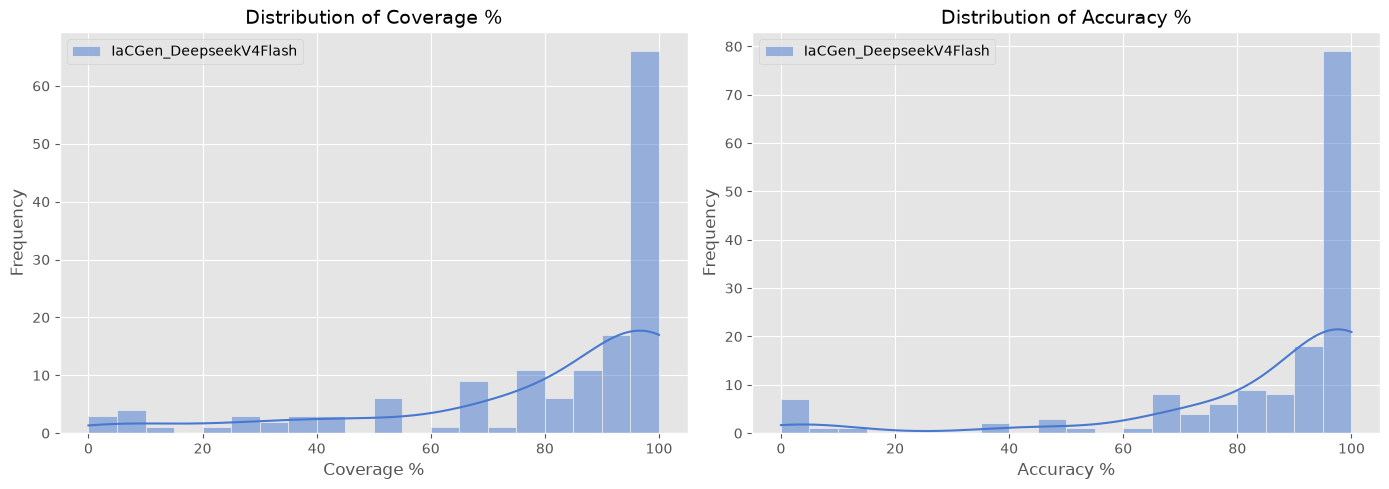

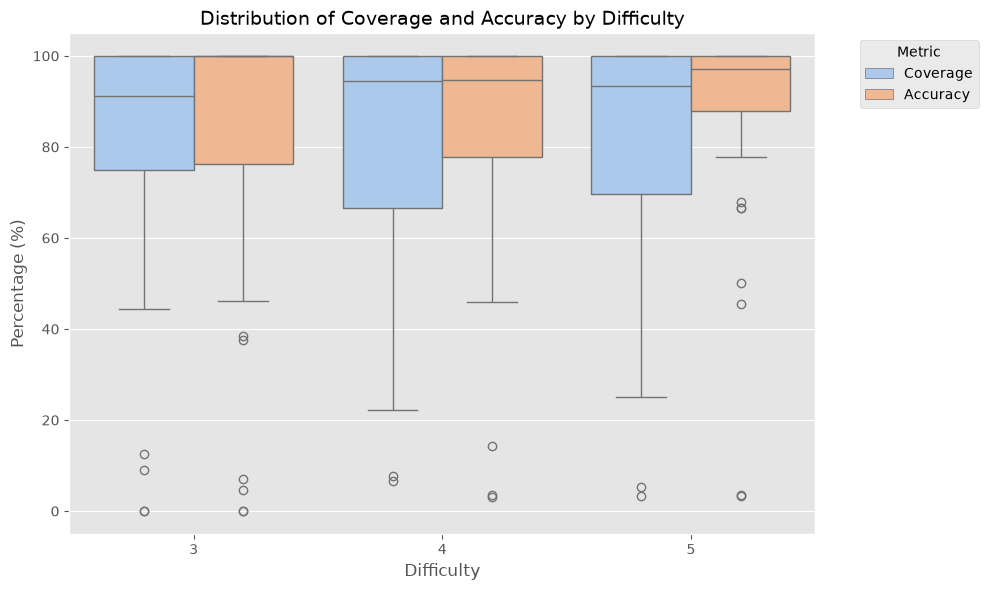

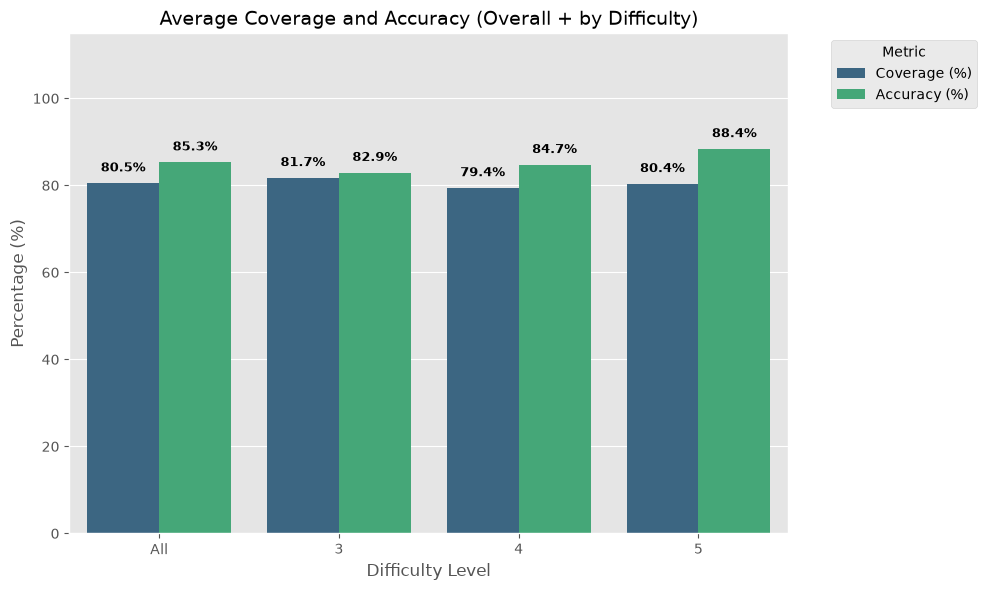

In [7]:
# ── 6. Coverage & Accuracy Distributions ───────────────────────────────────
plt.figure(figsize=(14, 5))
for model_name, df in normalized_dataframes.items():
    scored = df[df["coverage_pct"].notna()]
    plt.subplot(1, 2, 1)
    sns.histplot(scored["coverage_pct"], bins=20, kde=True, label=model_name, alpha=0.5)
    plt.title("Distribution of Coverage %", fontsize=14)
    plt.xlabel("Coverage %")
    plt.ylabel("Frequency")
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(scored["accuracy_pct"], bins=20, kde=True, label=model_name, alpha=0.5)
    plt.title("Distribution of Accuracy %", fontsize=14)
    plt.xlabel("Accuracy %")
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()

# Coverage/accuracy by difficulty, boxplot
box_data = []
for model_name, df in normalized_dataframes.items():
    scored = df[df["coverage_pct"].notna()]
    for _, row in scored.iterrows():
        box_data.append({"Model": model_name, "Difficulty": row["difficulty"], "Metric": "Coverage", "Percentage": row["coverage_pct"]})
        box_data.append({"Model": model_name, "Difficulty": row["difficulty"], "Metric": "Accuracy", "Percentage": row["accuracy_pct"]})

if box_data:
    box_df = pd.DataFrame(box_data)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=box_df, x="Difficulty", y="Percentage", hue="Metric", palette="pastel")
    plt.title("Distribution of Coverage and Accuracy by Difficulty", fontsize=14)
    plt.ylabel("Percentage (%)")
    plt.ylim(-5, 105)
    plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# Average coverage/accuracy bar, with difficulty breakdown
avg_rows = []
for model_name, df in normalized_dataframes.items():
    scored = df[df["coverage_pct"].notna()]
    avg_rows.append({"Model": model_name, "Difficulty": "All", "Metric": "Coverage (%)", "Value": scored["coverage_pct"].mean()})
    avg_rows.append({"Model": model_name, "Difficulty": "All", "Metric": "Accuracy (%)", "Value": scored["accuracy_pct"].mean()})
    for diff in sorted(scored["difficulty"].dropna().unique()):
        d = scored[scored["difficulty"] == diff]
        avg_rows.append({"Model": model_name, "Difficulty": str(int(diff)), "Metric": "Coverage (%)", "Value": d["coverage_pct"].mean()})
        avg_rows.append({"Model": model_name, "Difficulty": str(int(diff)), "Metric": "Accuracy (%)", "Value": d["accuracy_pct"].mean()})

avg_df = pd.DataFrame(avg_rows)
order = ["All"] + sorted([d for d in avg_df["Difficulty"].unique() if d != "All"])
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=avg_df, x="Difficulty", y="Value", hue="Metric", order=order, palette="viridis")
plt.title("Average Coverage and Accuracy (Overall + by Difficulty)", fontsize=14)
plt.ylabel("Percentage (%)")
plt.xlabel("Difficulty Level")
plt.ylim(0, 115)
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height + 2, f"{height:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


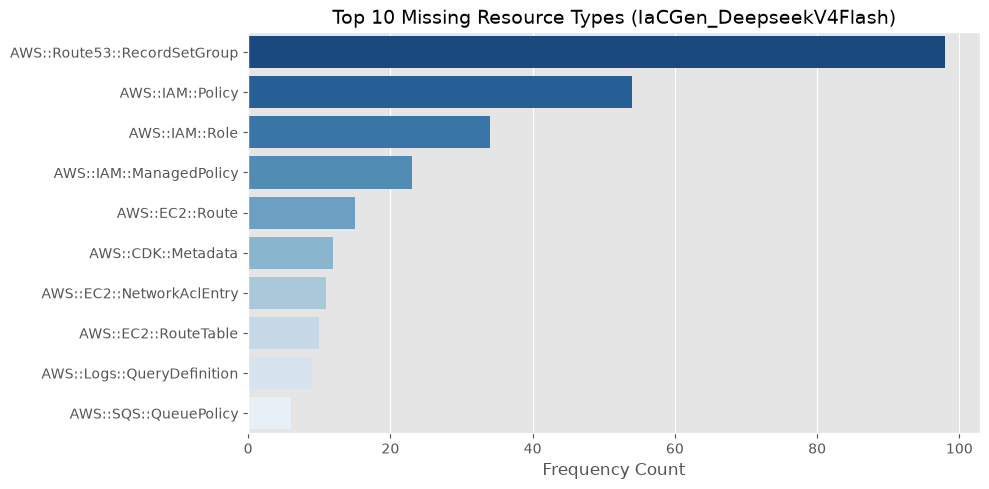

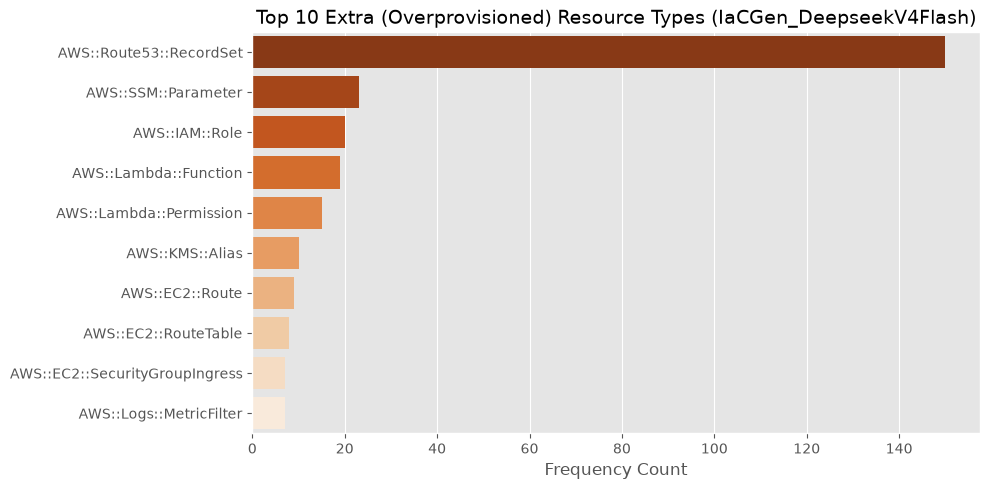

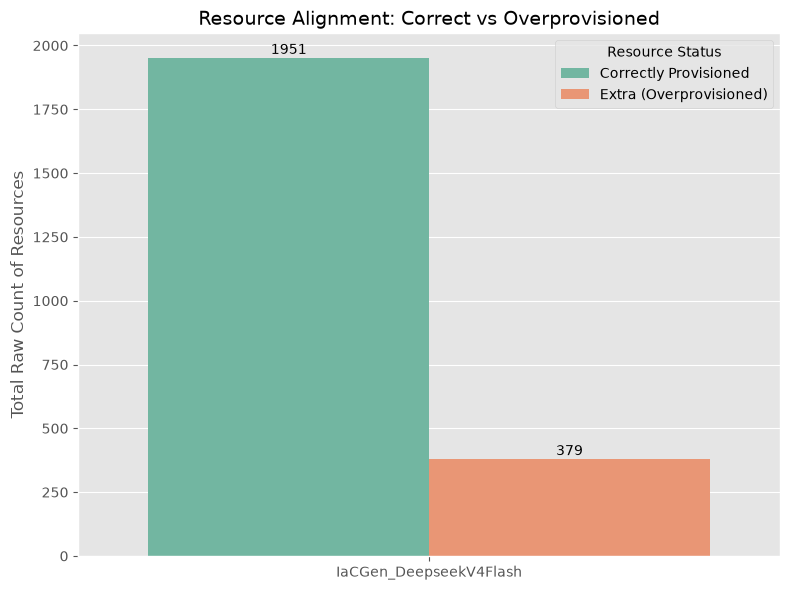

In [8]:
# ── 7. Top Missing and Extra Resource Types ────────────────────────────────
for model_name, df in normalized_dataframes.items():
    missing_counter, extra_counter = Counter(), Counter()
    for items in df["missing_resource_types"].dropna():
        missing_counter.update(items if isinstance(items, list) else [])
    for items in df["extra_resource_types"].dropna():
        extra_counter.update(items if isinstance(items, list) else [])

    top_missing = pd.DataFrame(missing_counter.most_common(10), columns=["Resource Type", "Frequency"])
    top_extra = pd.DataFrame(extra_counter.most_common(10), columns=["Resource Type", "Frequency"])

    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_missing, y="Resource Type", x="Frequency", hue="Resource Type", palette="Blues_r", legend=False)
        plt.title(f"Top 10 Missing Resource Types ({model_name})", fontsize=14)
        plt.xlabel("Frequency Count")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

    if not top_extra.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_extra, y="Resource Type", x="Frequency", hue="Resource Type", palette="Oranges_r", legend=False)
        plt.title(f"Top 10 Extra (Overprovisioned) Resource Types ({model_name})", fontsize=14)
        plt.xlabel("Frequency Count")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

# ── 7b. Resource Alignment: Correct vs Overprovisioned ─────────────────────
overprov_rows = []
for model_name, df in normalized_dataframes.items():
    scored = df[df["coverage_pct"].notna()]
    overprov_rows.append({"Model": model_name, "Resource Status": "Correctly Provisioned", "Total": scored["correct_resources"].sum()})
    overprov_rows.append({"Model": model_name, "Resource Status": "Extra (Overprovisioned)", "Total": scored["extra_resources"].sum()})

over_df = pd.DataFrame(overprov_rows)
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=over_df, x="Model", y="Total", hue="Resource Status", palette="Set2")
plt.title("Resource Alignment: Correct vs Overprovisioned", fontsize=14)
plt.ylabel("Total Raw Count of Resources")
plt.xlabel("")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2., height + 3, f"{int(height)}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()



IaCGen_DeepseekV4Flash: 9/148 scenarios (6.1%) below 30% on both coverage and accuracy.
  ⚠️ 7 of those still PASSED (deployable + syntactically valid) despite the drift -- exactly the failure mode coverage/accuracy scoring exists to catch, since `success` alone would have hidden it.


,row_number,difficulty,coverage_pct,accuracy_pct,success,failed_at_stage,total_required_resources,total_generated_resources,correct_resources,missing_resources,extra_resources,ground_truth_path
0,11,3,0.000000,0.000000,False,yaml_validation,NaN,NaN,NaN,NaN,NaN,cfn_templates/sasmita1005__AWSSAM/apigw-websocket-api-sfn-async/template.yaml
1,34,3,0.000000,0.000000,False,yaml_validation,NaN,NaN,NaN,NaN,NaN,cfn_templates/Yoshiki0705__FSx-for-ONTAP-S3AccessPoints-Serverless-Patterns/...
2,94,5,3.225806,3.225806,True,NaN,31.0,31.0,1.0,30.0,30.0,cfn_templates/PRX__Infrastructure/dns/theworld.org-hosted-zone.yml
3,118,5,5.263158,3.448276,True,NaN,19.0,29.0,1.0,18.0,28.0,cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/temp...
4,60,4,6.666667,3.571429,True,NaN,15.0,28.0,1.0,14.0,27.0,cfn_templates/PRX__Infrastructure/dns/radiotopia.fm-hosted_zone.yml
5,89,4,7.692308,3.125000,True,NaN,13.0,32.0,1.0,12.0,31.0,cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/temp...
6,4,3,9.090909,4.545455,True,NaN,11.0,22.0,1.0,10.0,21.0,cfn_templates/Tianyi2__IRIS/data/cloudformation_collected_templates_new/temp...
7,38,3,12.500000,7.142857,True,NaN,8.0,14.0,1.0,7.0,13.0,cfn_templates/PRX__Infrastructure/dns/podcastgarage.org-hosted_zone.yml
8,61,4,25.000000,14.285714,True,NaN,8.0,14.0,2.0,6.0,12.0,cfn_templates_greenfield/aws-samples__sample-scientific-tools-on-amazon-bedr...


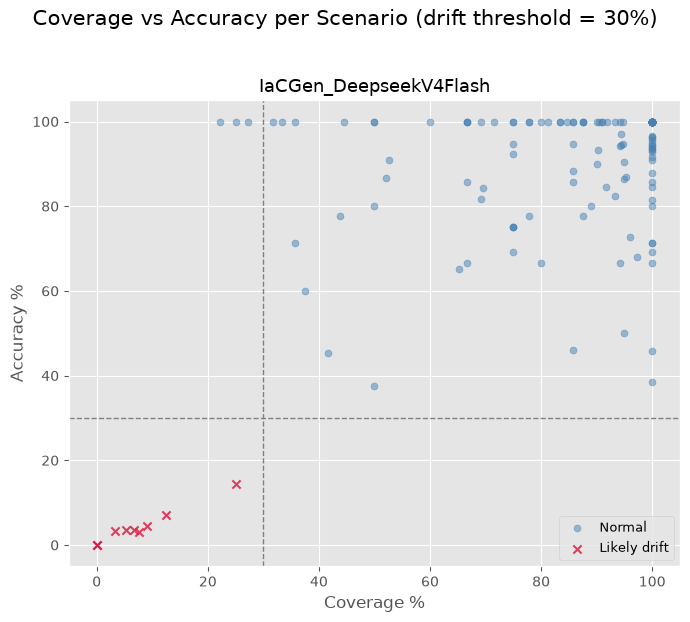

In [9]:
# ── 8. Low Coverage/Accuracy Scenario Audit (possible benchmark problems) ──
# Same triage this project's other audit notebooks apply: a scenario is
# flagged as "likely drift" only when BOTH coverage AND accuracy fall below
# the threshold together -- low coverage alone can mean "did the bare
# minimum but got it right", and low accuracy alone can mean "over-provisioned
# but covered everything asked" -- neither is "generated something unrelated
# to the prompt" on its own.
DRIFT_THRESHOLD_PCT = 30.0

scenario_diagnostics = {}
for model_name, df in normalized_dataframes.items():
    diag_df = df[df["coverage_pct"].notna()].copy()
    diag_df["likely_drift"] = (diag_df["coverage_pct"] < DRIFT_THRESHOLD_PCT) & (diag_df["accuracy_pct"] < DRIFT_THRESHOLD_PCT)
    scenario_diagnostics[model_name] = diag_df

    n_total, n_flagged = len(diag_df), int(diag_df["likely_drift"].sum())
    n_flagged_but_success = int((diag_df["likely_drift"] & (diag_df["success"] == True)).sum())

    print(f"\n{'='*90}\n{model_name}: {n_flagged}/{n_total} scenarios ({n_flagged / n_total:.1%}) "
          f"below {DRIFT_THRESHOLD_PCT:.0f}% on both coverage and accuracy.")
    if n_flagged_but_success:
        print(f"  ⚠️ {n_flagged_but_success} of those still PASSED (deployable + syntactically valid) despite the "
              f"drift -- exactly the failure mode coverage/accuracy scoring exists to catch, since `success` alone "
              f"would have hidden it.")

    if n_flagged:
        display_cols = ["row_number", "difficulty", "coverage_pct", "accuracy_pct", "success", "failed_at_stage",
                         "total_required_resources", "total_generated_resources", "correct_resources",
                         "missing_resources", "extra_resources", "ground_truth_path"]
        flagged = diag_df[diag_df["likely_drift"]].sort_values("coverage_pct")[display_cols].reset_index(drop=True)
        with pd.option_context("display.max_colwidth", 80, "display.width", 200):
            display(flagged)

if scenario_diagnostics:
    n_models = len(scenario_diagnostics)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)
    for ax, (model_name, diag_df) in zip(axes[0], scenario_diagnostics.items()):
        ok, bad = diag_df[~diag_df["likely_drift"]], diag_df[diag_df["likely_drift"]]
        ax.scatter(ok["coverage_pct"], ok["accuracy_pct"], alpha=0.5, s=25, label="Normal", color="steelblue")
        ax.scatter(bad["coverage_pct"], bad["accuracy_pct"], alpha=0.8, s=35, label="Likely drift", color="crimson", marker="x")
        ax.axvline(DRIFT_THRESHOLD_PCT, color="gray", linestyle="--", linewidth=1)
        ax.axhline(DRIFT_THRESHOLD_PCT, color="gray", linestyle="--", linewidth=1)
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel("Coverage %")
        ax.set_ylabel("Accuracy %")
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.legend(loc="lower right", fontsize=9)
    fig.suptitle(f"Coverage vs Accuracy per Scenario (drift threshold = {DRIFT_THRESHOLD_PCT:.0f}%)", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()


## 4. Common Failure Patterns — Success vs Failed Scenarios

In [10]:
# ── 9. Common Failure Patterns per Validation Stage ─────────────────────────
# `deepseek-v4-flash_error_history.csv` has one row per error IaCGen's own
# feedback loop saw, across every iteration of every scenario -- unlike the
# IaCGOD result CSVs used elsewhere in this project, these messages carry no
# bracketed error code ([E3002], [AWS-0132], ...); cfn-lint/yamllint/AWS
# deploy errors here are free text. So instead of extracting a code, each
# message is classified into a small set of recognizable signature buckets
# (same technique as the deploy-failure clustering used for the CFN/TF
# tracks), and each bucket is labeled with a real example message so the
# plot stays readable rather than just showing a bucket name.
#
# Two views, matching what was asked -- top errors for scenarios that
# ultimately SUCCEEDED (errors hit and recovered from along the way) vs. ones
# that ultimately FAILED (errors that were never resolved) -- split per stage,
# since IaCGen gates sequentially (YAML -> syntax/cfn-lint -> deploy) and a
# stage's errors only mean something in the context of that stage.

DEPLOY_SIGNATURES = [
    ("Resource creation cancelled (rollback bystander)", re.compile(r"creation cancelled", re.I)),
    ("Invalid CIDR block", re.compile(r"invalid CIDR", re.I)),
    ("Missing required Parameters (no default supplied)", re.compile(r"must have values", re.I)),
    ("Resource did not stabilize / timed out", re.compile(r"did not stabilize|timed?\s*out", re.I)),
    ("Account/service prerequisite not enabled", re.compile(r"is not enabled|not authorized to perform|AccessDenied", re.I)),
    ("Quota / limit exceeded", re.compile(r"maximum number of|limit exceeded|quota", re.I)),
    ("Schema / definition validation failed", re.compile(r"SCHEMA_VALIDATION_FAILED|Invalid .*Definition", re.I)),
    ("Already exists", re.compile(r"already exists", re.I)),
    ("Missing stack CAPABILITY_* (IAM resources need it)", re.compile(r"InsufficientCapabilitiesException|Requires capabilities", re.I)),
    ("Custom resource failed (see CloudWatch)", re.compile(r"custom resource", re.I)),
    ("Validation failed (generic, needs DescribeEvents)", re.compile(r"Validation failed with \d+ error", re.I)),
    ("Invalid parameter/request value", re.compile(r"invalid (parameter|request)", re.I)),
]
SYNTAX_SIGNATURES = [
    ("Missing required property", re.compile(r"is a required property", re.I)),
    ("Unexpected / extra property", re.compile(r"Additional properties are not allowed", re.I)),
    ("Value not in allowed enum", re.compile(r"is not one of \[", re.I)),
    ("Type mismatch", re.compile(r"is not of type", re.I)),
    ("Value doesn't match required pattern", re.compile(r"is not a .* with pattern", re.I)),
    ("Redundant DependsOn (implicit dependency already exists)", re.compile(r"dependency already enforced", re.I)),
    ("Unused Condition/Parameter/Mapping", re.compile(r"^(Condition|Parameter|Mapping) .* (not used|is defined but not used)", re.I)),
    ("Circular dependency", re.compile(r"[Cc]ircular [Dd]ependenc", re.I)),
    ("Deprecated runtime", re.compile(r"was deprecated on|is not a supported runtime", re.I)),
    ("Unnecessary intrinsic function (no variables to substitute)", re.compile(r"isn't needed because there are no variables", re.I)),
]
YAML_SIGNATURES = [
    ("Mapping syntax error", re.compile(r"mapping values are not allowed", re.I)),
    ("Missing colon", re.compile(r"could not find expected ':'", re.I)),
    ("Malformed flow sequence/mapping", re.compile(r"expected ',' or '[\]}]'", re.I)),
    ("Duplicate key", re.compile(r"duplication of key", re.I)),
    ("Wrong indentation", re.compile(r"wrong indentation", re.I)),
    ("Extra whitespace in brackets/braces", re.compile(r"too many spaces inside (brackets|braces)", re.I)),
    ("Sequence syntax error", re.compile(r"sequence entries are not allowed", re.I)),
    ("Unexpected end of stream", re.compile(r"unexpected end of stream|found character.*that cannot start", re.I)),
]
STAGE_SIGNATURES = {"yaml_validation": YAML_SIGNATURES, "syntax_validation": SYNTAX_SIGNATURES, "deployment": DEPLOY_SIGNATURES}

def truncate_msg(msg: str, width: int = 45) -> str:
    msg = re.sub(r"\s+", " ", str(msg)).strip()
    return msg if len(msg) <= width else msg[: width - 1].rstrip() + "…"

def classify_bucket(msg, signatures) -> str:
    if not isinstance(msg, str) or not msg.strip():
        return None
    first = re.sub(r"^Line\s+\d+:\s*", "", msg.split("|")[0].strip())
    for label, pat in signatures:
        if pat.search(first):
            return label
    return "Other (see message)"

def keep_last_run_only(eh: pd.DataFrame, rerun_row_numbers: set, gap_hours: float = 2.0) -> pd.DataFrame:
    """Mirrors the results-CSV dedup (keep the most recent full rerun) for the
    handful of row_numbers confirmed to have been run twice -- error_history.csv
    has no run-attempt id, so a rerun is detected as a large time gap between
    consecutive timestamps for that specific row_number only (never applied to a
    row that wasn't already confirmed rerun, since a normal pause between
    iterations isn't evidence of a second full run on its own)."""
    if not rerun_row_numbers:
        return eh
    unaffected = eh[~eh["row_number"].isin(rerun_row_numbers)]
    fixed = []
    for rn, g in eh[eh["row_number"].isin(rerun_row_numbers)].groupby("row_number"):
        g = g.sort_values("timestamp")
        gaps = g["timestamp"].diff().dt.total_seconds() / 3600.0
        run_id = (gaps > gap_hours).cumsum()
        fixed.append(g[run_id == run_id.max()])
    return pd.concat([unaffected] + fixed, ignore_index=True)

error_histories = {}
for pair in input_pairs:
    model = pair["model_name"]
    raw_results = pd.read_csv(pair["results_csv"])
    rerun_row_numbers = set(raw_results.loc[raw_results.duplicated(subset="row_number", keep=False), "row_number"])

    eh = pd.read_csv(pair["error_history_csv"])
    eh["timestamp"] = pd.to_datetime(eh["timestamp"])
    eh = keep_last_run_only(eh, rerun_row_numbers)

    df = normalized_dataframes[model]
    eh = eh.merge(df[["row_number", "success", "difficulty"]], on="row_number", how="inner")
    error_histories[model] = eh
    print(f"📁 {model}: {len(eh)} error-history rows joined to {eh['row_number'].nunique()} scenarios "
          f"({int(eh.groupby('row_number')['success'].first().sum())} of which ultimately succeeded).")


📁 IaCGen_DeepseekV4Flash: 3155 error-history rows joined to 131 scenarios (107 of which ultimately succeeded).


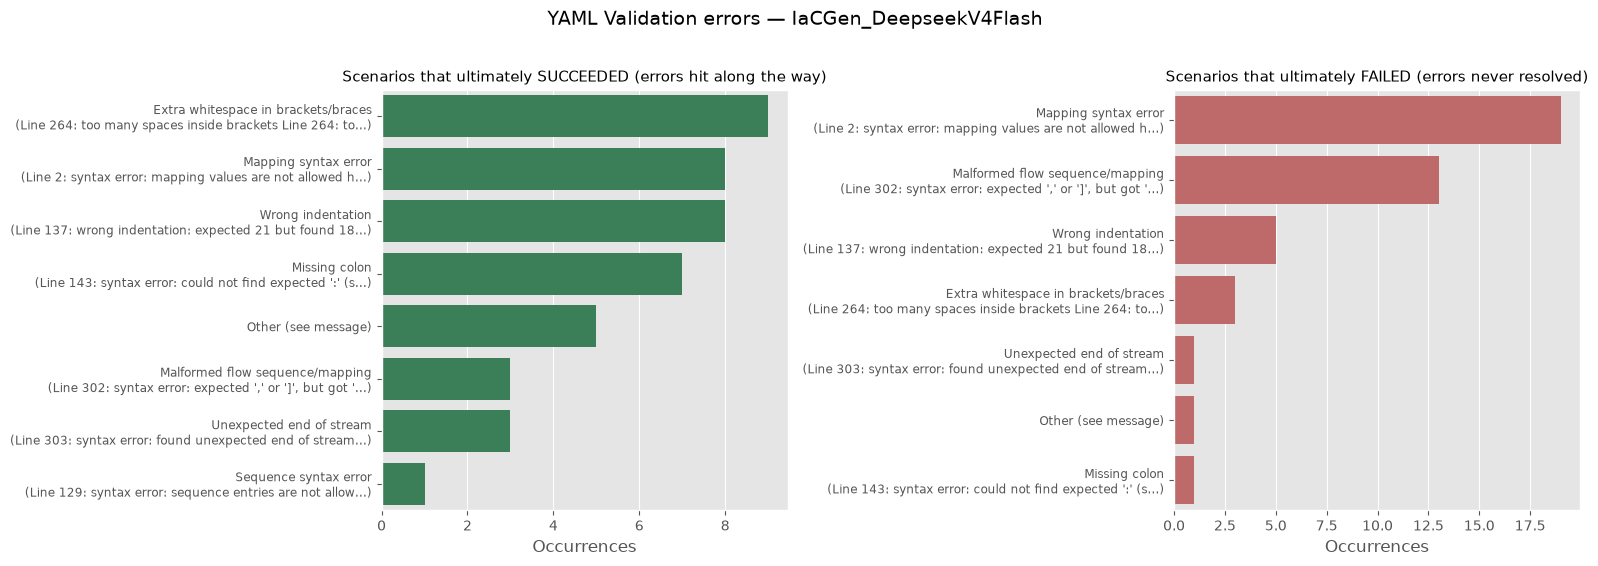

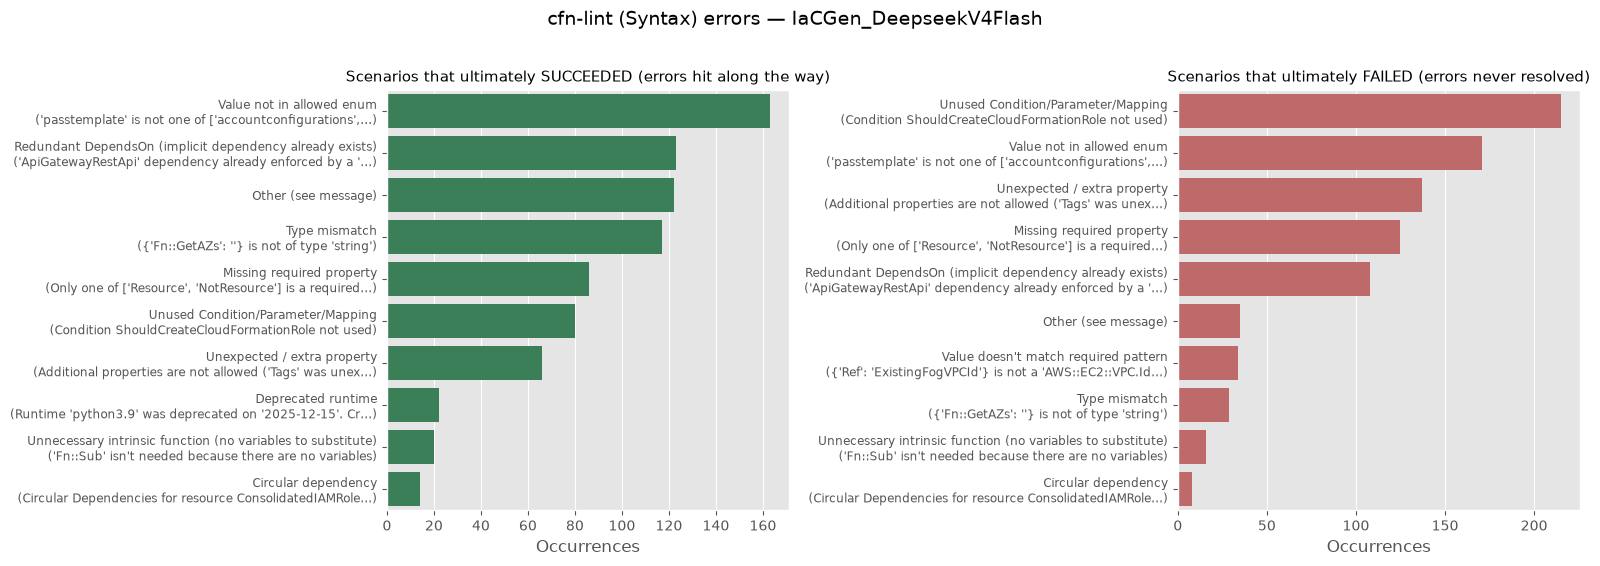

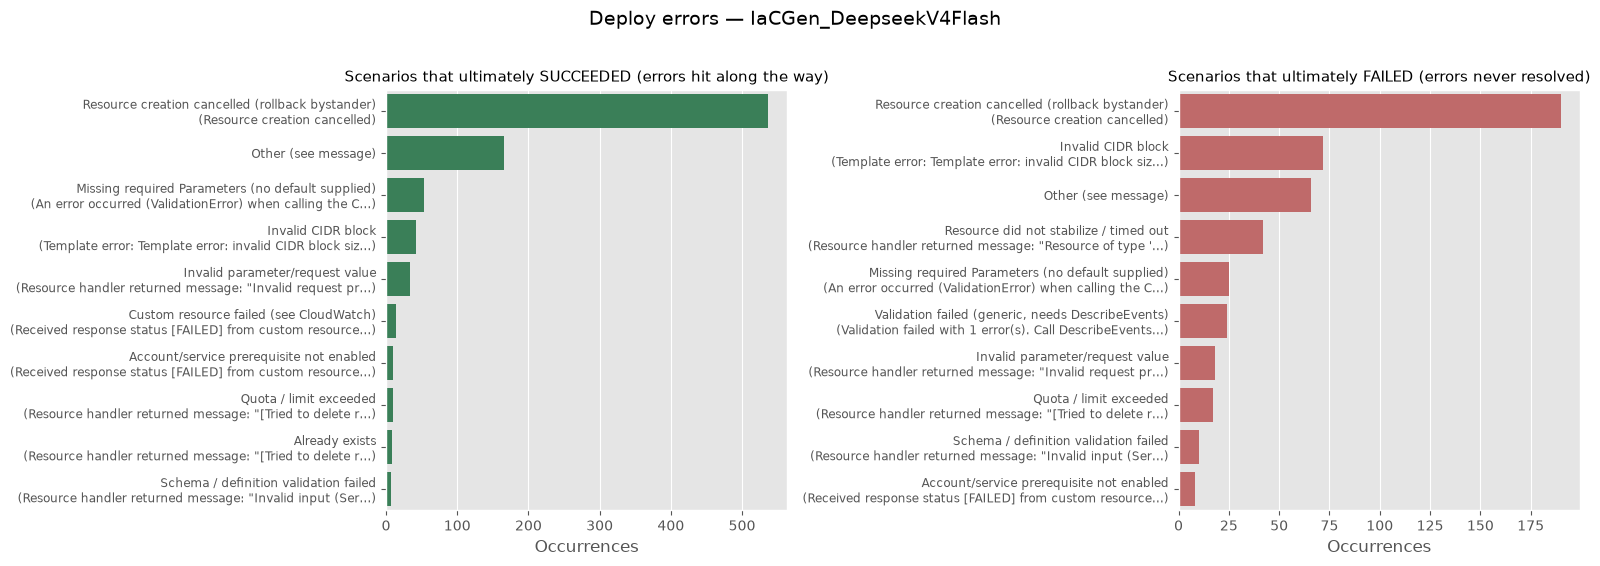

In [11]:
# ── 10. Top Errors — Success vs Failed Scenarios, per Stage ────────────────
STAGE_TITLES = {"yaml_validation": "YAML Validation", "syntax_validation": "cfn-lint (Syntax)", "deployment": "Deploy"}

for model_name, eh in error_histories.items():
    for stage, signatures in STAGE_SIGNATURES.items():
        stage_eh = eh[eh["error_stage"] == stage]
        if stage_eh.empty:
            continue

        bucket_examples = defaultdict(Counter)  # bucket -> Counter(example message)
        def bucket_series(sub):
            counter = Counter()
            for msg in sub["error_message"].dropna():
                b = classify_bucket(msg, signatures)
                if b is None:
                    continue
                counter[b] += 1
                if b != "Other (see message)":
                    bucket_examples[b][msg] += 1
            return counter

        success_counter = bucket_series(stage_eh[stage_eh["success"] == True])
        failed_counter = bucket_series(stage_eh[stage_eh["success"] == False])
        if not success_counter and not failed_counter:
            continue

        def label_for(bucket):
            ex = bucket_examples.get(bucket)
            if not ex:
                return bucket
            example, _ = ex.most_common(1)[0]
            return f"{bucket}\n({truncate_msg(example, 55)})"

        fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
        for ax, counter, title, color in [
            (axes[0], success_counter, "Scenarios that ultimately SUCCEEDED (errors hit along the way)", "seagreen"),
            (axes[1], failed_counter, "Scenarios that ultimately FAILED (errors never resolved)", "indianred"),
        ]:
            top = pd.DataFrame(counter.most_common(10), columns=["Bucket", "Count"])
            if top.empty:
                ax.text(0.5, 0.5, "No errors", ha="center", va="center")
                ax.set_axis_off()
                continue
            top["Label"] = top["Bucket"].apply(label_for)
            sns.barplot(data=top, y="Label", x="Count", color=color, ax=ax)
            ax.set_title(title, fontsize=10.5)
            ax.set_xlabel("Occurrences")
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelsize=8.5)
        fig.suptitle(f"{STAGE_TITLES[stage]} errors — {model_name}", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()


## 5. Effort vs Outcome

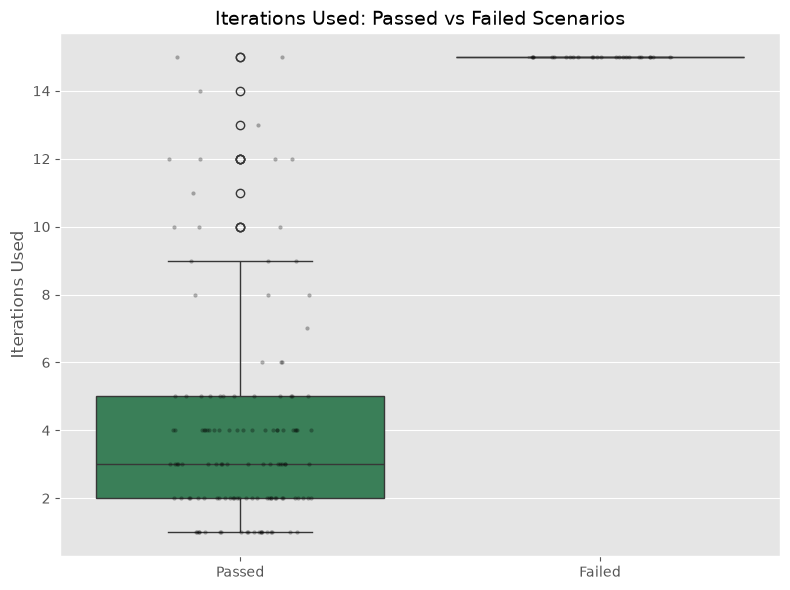

📊 Mean iterations by outcome:


mean  median  max  count
Model                  Outcome                           
IaCGen_DeepseekV4Flash Failed   15.00    15.0   15     24
                       Passed    4.06     3.0   15    126


  IaCGen_DeepseekV4Flash: 24/24 failed scenarios (100%) hit the observed max iteration budget (15) before giving up -- the rest failed before exhausting their budget.


In [12]:
# ── 11. Effort vs Outcome (iterations used) ─────────────────────────────────
# No token/cost/duration data is available for this baseline (IaCGen's own
# results CSV doesn't record it), so this is scoped to iteration count only.
effort_rows = []
for model_name, df in normalized_dataframes.items():
    outcome = df["success"].map({True: "Passed", False: "Failed"})
    effort_rows.append(pd.DataFrame({"Model": model_name, "Outcome": outcome, "Iterations Used": df["total_iterations"]}))

effort_df = pd.concat(effort_rows, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.boxplot(data=effort_df, x="Outcome", y="Iterations Used", hue="Outcome",
            palette={"Passed": "seagreen", "Failed": "indianred"}, legend=False)
sns.stripplot(data=effort_df, x="Outcome", y="Iterations Used", color="black", alpha=0.3, size=3, jitter=0.2)
plt.title("Iterations Used: Passed vs Failed Scenarios", fontsize=14)
plt.ylabel("Iterations Used")
plt.xlabel("")
plt.tight_layout()
plt.show()

print("📊 Mean iterations by outcome:")
display(effort_df.groupby(["Model", "Outcome"])["Iterations Used"].agg(["mean", "median", "max", "count"]).round(2))

for model_name, df in normalized_dataframes.items():
    max_iter = df["total_iterations"].max()
    failed = df[df["success"] == False]
    exhausted = failed[failed["total_iterations"] >= max_iter]
    if len(failed):
        print(f"\n  {model_name}: {len(exhausted)}/{len(failed)} failed scenarios "
              f"({len(exhausted) / len(failed):.0%}) hit the observed max iteration budget ({max_iter:.0f}) "
              f"before giving up -- the rest failed before exhausting their budget.")


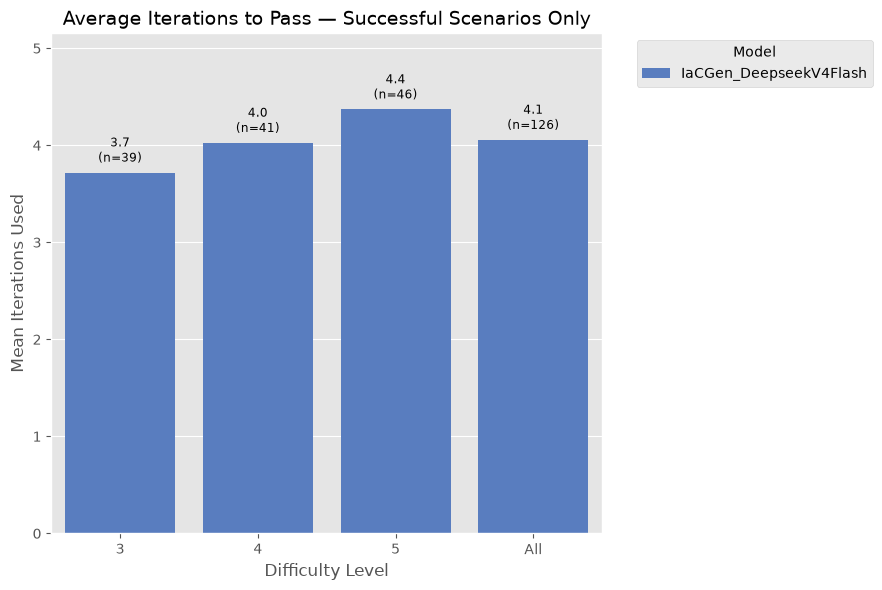

📊 Average iterations to pass, by difficulty (successful scenarios only):


,Model,Difficulty Level,N Passed,Mean Iterations,Median Iterations
0,IaCGen_DeepseekV4Flash,3,39,3.72,3.0
1,IaCGen_DeepseekV4Flash,4,41,4.02,3.0
2,IaCGen_DeepseekV4Flash,5,46,4.37,4.0
3,IaCGen_DeepseekV4Flash,All,126,4.06,3.0


In [13]:
# ── 11b. Average Iterations to Pass (Successful Scenarios Only) ────────────
# The Effort-vs-Outcome cell above already shows iterations split by
# Passed/Failed -- this drills into just the Passed side by difficulty, to
# answer a narrower, practical question: "for a scenario this hard, how many
# repair iterations should we budget for before the agent typically
# converges?" Failed scenarios are excluded entirely here since their
# iteration count just reflects the max-iteration cap, not genuine effort-
# to-converge (see the "hit the observed max iteration budget" finding
# above).
avg_iter_rows = []
for model_name, df in normalized_dataframes.items():
    passed = df[df["success"] == True]
    grouped = passed.groupby("difficulty")["total_iterations"].agg(["mean", "median", "count"])
    for diff, row in grouped.iterrows():
        avg_iter_rows.append({
            "Model": model_name, "Difficulty Level": diff,
            "Mean Iterations": row["mean"], "Median Iterations": row["median"], "N Passed": int(row["count"]),
        })
    if len(passed):
        avg_iter_rows.append({
            "Model": model_name, "Difficulty Level": "All",
            "Mean Iterations": passed["total_iterations"].mean(),
            "Median Iterations": passed["total_iterations"].median(), "N Passed": len(passed),
        })

if avg_iter_rows:
    avg_iter_df = pd.DataFrame(avg_iter_rows)
    order = sorted([d for d in avg_iter_df["Difficulty Level"].unique() if d != "All"]) + ["All"]
    avg_iter_df["Difficulty Level"] = pd.Categorical(avg_iter_df["Difficulty Level"], categories=order, ordered=True)
    avg_iter_df = avg_iter_df.sort_values(["Difficulty Level", "Model"])

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(data=avg_iter_df, x="Difficulty Level", y="Mean Iterations", hue="Model", order=order)
    plt.title("Average Iterations to Pass — Successful Scenarios Only", fontsize=14)
    plt.ylim(0, avg_iter_df["Mean Iterations"].max() * 1.18)
    plt.ylabel("Mean Iterations Used")
    plt.xlabel("Difficulty Level")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    for i, container in enumerate(ax.containers):
        model_name = ax.get_legend().get_texts()[i].get_text()
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue
            diff_level = ax.get_xticklabels()[j].get_text()
            row = avg_iter_df[(avg_iter_df["Model"] == model_name) & (avg_iter_df["Difficulty Level"].astype(str) == diff_level)]
            if not row.empty:
                n = row["N Passed"].values[0]
                ax.annotate(f"{height:.1f}\n(n={n})", (p.get_x() + p.get_width() / 2., height),
                            ha="center", va="bottom", xytext=(0, 5), textcoords="offset points", fontsize=8.5)

    plt.tight_layout()
    plt.show()

    print("📊 Average iterations to pass, by difficulty (successful scenarios only):")
    display(avg_iter_df[["Model", "Difficulty Level", "N Passed", "Mean Iterations", "Median Iterations"]]
            .round(2).reset_index(drop=True))
else:
    print("⚠️ No models with total_iterations/success/difficulty columns found.")


## 6. Memory Analysis — Iteration-Level Convergence Behavior

Uses the conversation transcripts (feedback text) and the on-disk per-iteration templates to ask a question the results CSV alone can't answer: when a scenario never converges, is IaCGen's own feedback loop actually trying different fixes, or resubmitting the same broken resource untouched?

In [14]:
# ── 12. Memory Analysis — Parse Conversation Transcripts ──────────────────
# Each `conversation_row{N}_{success}_{timestamp}.txt` is the LLM's full
# feedback loop for one scenario: a system prompt, the initial business-need
# prompt, then alternating (feedback, revised template) pairs per iteration.
# One thing worth confirming before trusting these files for anything: the
# ASSISTANT's echoed "[Generated Template Content]" in each message turns out
# to be truncated to IaCGen's own `TEMPLATE_SHOWN_CHARACTERS = 1000` preview
# length (Code/main.py) -- every assistant message in this run is exactly
# ~1032 characters regardless of the real template's size, confirmed by the
# tail of a checked message cutting off mid-ARN. So the conversation files
# are NOT a reliable source for full per-iteration template content -- that
# still has to come from the separate `row_N_update_M_template_*.yaml` files
# on disk (used in §13 below). What the conversation files ARE reliable for
# is the FEEDBACK text itself (the user-role messages) -- unlike the
# assistant's echo, these are never truncated (confirmed: their lengths vary
# naturally with how many errors were reported, not clustered at a fixed cap).

MSG_SPLIT_RE = re.compile(r"\n={10,}\n")
MSG_HEADER_RE = re.compile(r"^Message (\d+)\nRole: (\w+)\n-{5,}\n(.*)$", re.S)
FEEDBACK_STAGE_RE = re.compile(r"failed at the (\w+) stage", re.I)

def parse_conversation(path: str) -> list:
    text = open(path, encoding="utf-8", errors="replace").read()
    messages = []
    for b in MSG_SPLIT_RE.split(text):
        m = MSG_HEADER_RE.match(b.strip())
        if m:
            messages.append({"msg_num": int(m.group(1)), "role": m.group(2), "content": m.group(3).strip()})
    return messages

for pair in input_pairs:
    model = pair["model_name"]
    df = normalized_dataframes[model]
    conv_files = {}
    for f in glob.glob(os.path.join(pair["templates_dir"], "conversation_row*.txt")):
        m = re.match(r"conversation_row(\d+)_", os.path.basename(f))
        if m:
            conv_files[int(m.group(1))] = f

    located = df["row_number"].isin(conv_files.keys())
    print(f"📁 {model}: {located.sum()}/{len(df)} scenarios have a locatable conversation transcript "
          f"({located.sum() / len(df):.0%}).")

    feedback_rows = []
    for _, row in df[located].iterrows():
        msgs = parse_conversation(conv_files[row["row_number"]])
        feedback_msgs = [m for m in msgs if m["role"] == "user" and m["msg_num"] > 2]
        for i, m in enumerate(feedback_msgs, start=1):
            stage_m = FEEDBACK_STAGE_RE.search(m["content"])
            feedback_rows.append({
                "row_number": row["row_number"], "iteration_after": i,
                "feedback_stage": stage_m.group(1) if stage_m else None,
                "feedback_word_count": len(m["content"].split()),
            })

    conversation_feedback = pd.DataFrame(feedback_rows)
    globals()[f"conversation_feedback_{model}"] = conversation_feedback

    mean_fb = conversation_feedback.groupby("row_number").size().mean() if not conversation_feedback.empty else 0
    print(f"   {len(conversation_feedback)} feedback message(s) parsed across {conversation_feedback['row_number'].nunique()} scenarios "
          f"(mean {mean_fb:.1f} feedback rounds/scenario); mean feedback length "
          f"{conversation_feedback['feedback_word_count'].mean():.0f} words.")

    # Integrity check: feedback-message count for a scenario should be
    # total_iterations - 1 (no feedback follows the very first attempt, and
    # none follows the last if it succeeded) or total_iterations (if it
    # still failed after the final attempt) -- never more.
    fb_counts = conversation_feedback.groupby("row_number").size()
    check = df[located].set_index("row_number")["total_iterations"]
    over = fb_counts[fb_counts > check.reindex(fb_counts.index)]
    if len(over):
        print(f"   ⚠️ {len(over)} scenario(s) have MORE feedback messages than total_iterations -- unexpected, worth a second look.")


📁 IaCGen_DeepseekV4Flash: 150/150 scenarios have a locatable conversation transcript (100%).
   745 feedback message(s) parsed across 130 scenarios (mean 5.7 feedback rounds/scenario); mean feedback length 149 words.


📊 IaCGen_DeepseekV4Flash:
   47 scenario(s) had a (resource, stage) error disappear then reappear in a later iteration.
   9 scenario(s) had a (resource, stage) error present in EVERY iteration -- IaCGen's loop never cleared it.


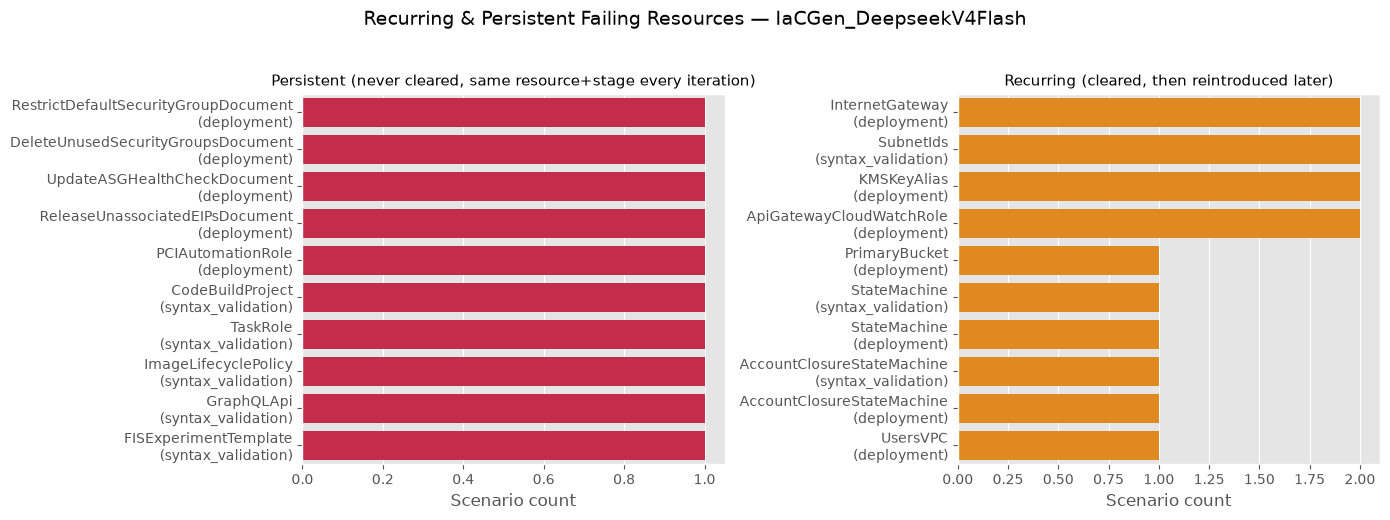


   Persistent-failure detail (every scenario where a resource never got fixed):


,row_number,resource_name,stage,iterations
0,1,RestrictDefaultSecurityGroupDocument,deployment,"[1, 2, 3]"
1,1,DeleteUnusedSecurityGroupsDocument,deployment,"[1, 2, 3]"
2,1,UpdateASGHealthCheckDocument,deployment,"[1, 2, 3]"
3,1,ReleaseUnassociatedEIPsDocument,deployment,"[1, 2, 3]"
4,1,PCIAutomationRole,deployment,"[1, 2, 3]"
5,2,CodeBuildProject,syntax_validation,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]"
6,7,TaskRole,syntax_validation,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]"
7,21,ImageLifecyclePolicy,syntax_validation,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]"
8,31,GraphQLApi,syntax_validation,"[1, 2]"
9,80,FISExperimentTemplate,syntax_validation,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]"


In [15]:
# ── 13. Recurring & Persistent Failing Resources ────────────────────────────
# `error_history.csv` has a `resource_name` per error, at iteration
# granularity -- richer than anything in the results CSV. That makes it
# possible to ask the same question this project's IaCGOD notebooks ask of
# their own remediator: does the SAME resource keep failing iteration after
# iteration despite feedback (persistent -- IaCGen's loop never manages to
# clear it), or does it clear and then come back (recurring -- a later
# revision reintroduces the same problem)? Both are signs of a feedback loop
# that isn't converging, distinct from "took a few tries but got there."
for pair in input_pairs:
    model = pair["model_name"]
    eh = pd.read_csv(pair["error_history_csv"])

    recur_counter, persist_counter = Counter(), Counter()
    persistent_cases = []  # (row_number, resource_name, stage, iterations)
    n_recurring_rows, n_persistent_rows = 0, 0

    for rn, g in eh.groupby("row_number"):
        occ = defaultdict(list)
        for _, r in g.iterrows():
            if pd.isna(r["resource_name"]):
                continue
            occ[(r["resource_name"], r["error_stage"])].append(r["iteration_number"])

        all_iters = sorted(g["iteration_number"].unique())
        row_recur = row_persist = False
        for key, iters in occ.items():
            iters = sorted(set(iters))
            if len(iters) > 1 and (iters[-1] - iters[0]) > (len(iters) - 1):
                recur_counter[key] += 1
                row_recur = True
            elif len(all_iters) > 1 and len(iters) == len(all_iters):
                persist_counter[key] += 1
                row_persist = True
                persistent_cases.append({"row_number": rn, "resource_name": key[0], "stage": key[1], "iterations": iters})
        n_recurring_rows += row_recur
        n_persistent_rows += row_persist

    persistent_df = pd.DataFrame(persistent_cases)
    globals()[f"persistent_failures_{model}"] = persistent_df

    print(f"📊 {model}:")
    print(f"   {n_recurring_rows} scenario(s) had a (resource, stage) error disappear then reappear in a later iteration.")
    print(f"   {n_persistent_rows} scenario(s) had a (resource, stage) error present in EVERY iteration -- IaCGen's loop never cleared it.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, counter, title, color in [
        (axes[0], persist_counter, "Persistent (never cleared, same resource+stage every iteration)", "crimson"),
        (axes[1], recur_counter, "Recurring (cleared, then reintroduced later)", "darkorange"),
    ]:
        top = pd.DataFrame([(f"{k[0]}\n({k[1]})", v) for k, v in counter.most_common(10)], columns=["Resource (stage)", "Count"])
        if top.empty:
            ax.text(0.5, 0.5, "None", ha="center", va="center")
            ax.set_axis_off()
            continue
        sns.barplot(data=top, y="Resource (stage)", x="Count", color=color, ax=ax)
        ax.set_title(title, fontsize=10.5)
        ax.set_xlabel("Scenario count")
        ax.set_ylabel("")
    fig.suptitle(f"Recurring & Persistent Failing Resources — {model}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    if not persistent_df.empty:
        print("\n   Persistent-failure detail (every scenario where a resource never got fixed):")
        with pd.option_context("display.max_colwidth", 60):
            display(persistent_df)


📊 IaCGen_DeepseekV4Flash: of 24 persistent-failure cases traced through their on-disk iteration history --
    12  Repeatedly revised, still broken
    12  Never touched (same definition every time)


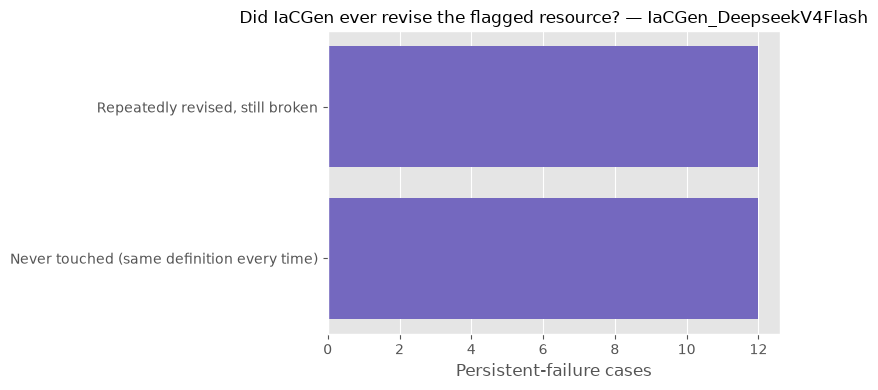

,row_number,resource_name,stage,n_iterations_traced,n_distinct_versions,classification
0,1,RestrictDefaultSecurityGroupDocument,deployment,4,4,"Repeatedly revised, still broken"
1,1,DeleteUnusedSecurityGroupsDocument,deployment,4,4,"Repeatedly revised, still broken"
2,1,UpdateASGHealthCheckDocument,deployment,4,4,"Repeatedly revised, still broken"
3,1,ReleaseUnassociatedEIPsDocument,deployment,4,4,"Repeatedly revised, still broken"
4,1,PCIAutomationRole,deployment,4,1,Never touched (same definition every time)
5,2,CodeBuildProject,syntax_validation,15,3,"Repeatedly revised, still broken"
6,7,TaskRole,syntax_validation,15,1,Never touched (same definition every time)
7,21,ImageLifecyclePolicy,syntax_validation,25,10,"Repeatedly revised, still broken"
8,31,GraphQLApi,syntax_validation,3,3,"Repeatedly revised, still broken"
9,80,FISExperimentTemplate,syntax_validation,15,4,"Repeatedly revised, still broken"


In [16]:
# ── 14. Did IaCGen Ever Actually Touch the Flagged Resource? ───────────────
# For every persistent failure found above, the on-disk per-iteration
# templates (`row_N_update_M_template_*.yaml`, the same files §5's coverage
# calculation reads the FINAL one from) make it possible to go one step
# further than "it never got fixed": did the LLM ever even change that
# specific resource across the iterations where it kept failing, or did it
# resubmit the exact same broken definition every time? Two genuinely
# different failure modes -- "ignored the feedback entirely" vs. "kept
# trying different fixes but never landed on a working one" -- and only
# visible by diffing the actual resource block across iterations, not from
# any single iteration's error message alone.

def _iteration_files(templates_dir, row_number):
    files = glob.glob(os.path.join(templates_dir, f"row_{row_number}_update_*_template_*.yaml"))
    def upd_num(p):
        m = re.search(r"_update_(\d+)_template_", os.path.basename(p))
        return int(m.group(1)) if m else -1
    return sorted(files, key=upd_num)

def _resource_signature(resources, name):
    r = resources.get(name)
    return json.dumps(r, sort_keys=True, default=str) if r is not None else None

for pair in input_pairs:
    model = pair["model_name"]
    persistent_df = globals().get(f"persistent_failures_{model}")
    if persistent_df is None or persistent_df.empty:
        print(f"⚠️ {model}: no persistent failures to trace.")
        continue

    trace_rows = []
    for _, case in persistent_df.iterrows():
        files = _iteration_files(pair["templates_dir"], case["row_number"])
        sigs, parse_errors = [], 0
        for f in files:
            try:
                with open(f) as fh:
                    template = yaml.load(fh, Loader=_CFNLoader)
                resources = (template or {}).get("Resources", {}) or {}
                sigs.append(_resource_signature(resources, case["resource_name"]))
            except Exception:
                parse_errors += 1
                sigs.append("PARSE_ERROR")
        n_versions = len(set(s for s in sigs if s is not None))
        trace_rows.append({
            "row_number": case["row_number"], "resource_name": case["resource_name"], "stage": case["stage"],
            "n_iterations_traced": len(files), "n_distinct_versions": n_versions,
            "classification": "Never touched (same definition every time)" if n_versions <= 1
                               else "Repeatedly revised, still broken",
        })

    trace_df = pd.DataFrame(trace_rows)
    globals()[f"persistent_trace_{model}"] = trace_df

    print(f"📊 {model}: of {len(trace_df)} persistent-failure cases traced through their on-disk iteration history --")
    counts = trace_df["classification"].value_counts()
    for label, cnt in counts.items():
        print(f"   {cnt:3d}  {label}")

    counts_df = counts.rename_axis("Classification").reset_index(name="Count")
    plt.figure(figsize=(8, 4))
    sns.barplot(data=counts_df, y="Classification", x="Count", color="slateblue")
    plt.title(f"Did IaCGen ever revise the flagged resource? — {model}", fontsize=12)
    plt.xlabel("Persistent-failure cases")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    with pd.option_context("display.max_colwidth", 60):
        display(trace_df)


## Notes & Limitations

- **Matching is by content, not row_number.** IaCGen's own `row_number` is only a label it
  assigned during that run, not a stable identifier or a reliable positional index into the
  benchmark. Ground truth is recovered by matching each row's own `prompt` text against the
  benchmark's `prompt` column (after undoing a UTF-8-as-Latin-1 mojibake artifact in IaCGen's
  own CSV writer) — never by position. Deduplication is likewise by `ground_truth_path`, not
  `row_number`, so it also catches the same scenario being claimed by two *different*
  row_numbers, not just a literal row_number repeat. One scenario (`mcp-tool-template.yaml`)
  was found run twice end-to-end; the most recent rerun was kept.
- **2 templates couldn't be scored for coverage** (row 57: LLM emitted a typo'd `!Condtion`
  intrinsic tag; row 140: a ground-truth `.json` file has an illegal trailing comma) — both
  genuine content issues, not a bug in the coverage port; flagged explicitly in §3 rather than
  silently dropped.
- **No security-scanning stage**: this IaCGen baseline's pipeline is YAML → cfn-lint (syntax) →
  Deploy only — no Trivy/security stage exists to compare against IaCGOD's own results.
- **No token/cost/duration data**: not recorded by this baseline's results CSV, so §5 is scoped
  to iteration count only.
- **Conversation transcripts are not a reliable source of full per-iteration template
  content** — confirmed empirically: every assistant message's echoed
  "[Generated Template Content]" is truncated to IaCGen's own `TEMPLATE_SHOWN_CHARACTERS =
  1000`-character preview (`Code/main.py`), regardless of the real template's size. §6's
  resource-diffing uses the separate on-disk `row_N_update_M_template_*.yaml` files instead;
  the conversation transcripts are used only for their (unabridged) feedback text.
